In [1]:
import os
import pandas as pd
from all_class.get_df import Get_df
from all_class.output_HC import Output
from all_class.v_nucl import V_nucl
from all_class.get_pgen import Get_pgen
from all_class.output_MC import Output_MC
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data_directory_SC="../../GFRAL/topo_1/only_h/"
Positive=pd.read_table(data_directory_SC+"Positive.tsv",sep="\t")
Negative=pd.read_table(data_directory_SC+"Negative.tsv",sep="\t")

In [3]:
relevant_days_GFRAL = {}
relevant_days_GFRAL["topo_1"]=["D17","D25","D39","D46","D60","D67"]
relevant_days_GFRAL["topo_2"]=["D17","D25","D39","D46","D60","D67","D67_spleen"]
relevant_days_GFRAL["topo_3"]=["D3","D17","D25","D39","D60","D67"]
relevant_days_GFRAL["topo_4"]=["D3","D17","D39"]
relevant_days_GFRAL["topo_5"]=["D3","D17","D39"]

In [5]:
mice=["topo_1","topo_2","topo_3","topo_4","topo_5"]
df_read_GFRAL={}
for mouse in mice[:]: 
    df_read_GFRAL[mouse]={} 
    directory_GFRAL="../../GFRAL_bulk/GFRAL/{}/only_h/".format(mouse)
    for day in relevant_days_GFRAL[mouse]:
        df_read_GFRAL[mouse][day]=pd.read_table(directory_GFRAL+"{}/df_read.tsv".format(day))

In [ ]:
heavy_67=heavy_aligned[heavy_aligned["0"].str.contains("D67",regex=False)]
Mouse_1="1152"
Mouse_2="368"
Mouse_3="1149"
blood={}
spleen={}

blood["topo_1"]=heavy_67[heavy_67["0"].str.contains("1152")]
spleen["topo_1"]=blood["topo_1"][blood["topo_1"]["0"].str.contains("Spleen",regex=False)]
blood["topo_1"]=blood["topo_1"][blood["topo_1"]["0"].str.contains("blood",regex=False)]
blood["topo_2"]=heavy_67[heavy_67["0"].str.contains("368")]
spleen["topo_2"]=blood["topo_2"][blood["topo_2"]["0"].str.contains("Spleen",regex=False)]
blood["topo_2"]=blood["topo_2"][blood["topo_2"]["0"].str.contains("blood",regex=False)]
blood["topo_3"]=heavy_67[heavy_67["0"].str.contains("1149")]
spleen["topo_3"]=blood["topo_3"][blood["topo_3"]["0"].str.contains("Spleen",regex=False)]
blood["topo_3"]=blood["topo_3"][blood["topo_3"]["0"].str.contains("blood",regex=False)]

In [6]:
temp={}
for mouse in mice:
    temp[mouse] = pd.concat([df_read_GFRAL[mouse][day] for day in relevant_days_GFRAL[mouse]],ignore_index=True)
df_read_GFRAL_all=pd.concat([temp[mouse] for mouse in mice],ignore_index=True)
#hits_GFRAL=df_read_GFRAL_all[df_read_GFRAL_all.nb_freq>0.000961]
#hits_GFRAL=df_read_GFRAL_all[df_read_GFRAL_all.hits==True]

/tmp/ipykernel_36931/4157454246.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  temp[mouse] = pd.concat([df_read_GFRAL[mouse][day] for day in relevant_days_GFRAL[mouse]],ignore_index=True)


In [8]:
data_directory_SC="../../GFRAL/topo_1/only_h/"
Total_mice_aligned=pd.read_table(data_directory_SC+"total_mice_aligned.tsv",sep="\t")

In [9]:
Table_GFRAL=pd.read_excel(data_directory_SC+"GFRAL_tag.xlsx")

In [10]:
data_directory_SC="../../GFRAL/topo_1/only_h/"
all_single_cell=pd.read_table(data_directory_SC+"all_single_cell.tsv",sep="\t")
heavy=pd.read_table(data_directory_SC+"all_single_cell_heavy_aligned.tsv",sep="\t")

In [11]:
df_GFRAL=pd.read_table("../../GFRAL/topo_1/only_hdf_GFRAL.tsv",sep="\t")
df_bind=df_GFRAL[df_GFRAL.binding=="BINDER"]
df_non_bind=df_GFRAL[df_GFRAL.binding=="NON BINDER"]
df_weak_bind=df_GFRAL[df_GFRAL.binding=="WEAK BINDER"]

In [12]:
df_GFRAL["new_binding"]=df_GFRAL["binding"].str.replace("WEAK ","")

In [18]:
df_table=pd.DataFrame(df_GFRAL[["aaSeqHeavy","aaSeqLight","new_binding"]])

In [23]:
df_table.rename(columns={"new_binding":"Binding"},inplace=True)

In [73]:
# BULK SPLEEN VS BLOOD
cdr3_blood_spleen = {
    "Blood": set(df_read_GFRAL["topo_2"]["D67_spleen"]["aaSeqCDR3"].dropna()),
    "Spleen": set(df_read_GFRAL["topo_2"]["D67"]["aaSeqCDR3"].dropna()),
    
}


In [84]:
# SINGLE cell positive negative 
cdr3_pos_neg = {
    #"Sample 1": set(df_read_GFRAL_all["aaSeqCDR3"].dropna()),
    #"Single cell": set(heavy["aaSeqCDR3"].dropna()),
    #"Sample 2": set(heavy["aaSeqCDR3"].dropna()),
    "Positive": set(Total_mice_aligned[Total_mice_aligned.spe=="Positive"]["Heavy aaSeqCDR3"].dropna()),
    "Negative": set(Total_mice_aligned[Total_mice_aligned.spe=="Negative"]["Heavy aaSeqCDR3"].dropna())

}


In [86]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_b_pos_neg = {
    #"Bulk": set(df_read_GFRAL_all["aaSeqCDR3"].dropna()),
    #"Single cell": set(heavy["aaSeqCDR3"].dropna()),
    "Binders": set(df_GFRAL[df_GFRAL.new_binding=="BINDER"]["aaSeqCDR3"].dropna()),
    #"Non binders": set(df_GFRAL[df_GFRAL.new_binding=="NON BINDER"]["aaSeqCDR3"].dropna()),
    "Positive": set(Total_mice_aligned[Total_mice_aligned.spe=="Positive"]["Heavy aaSeqCDR3"].dropna()),
    "Negative": set(Total_mice_aligned[Total_mice_aligned.spe=="Negative"]["Heavy aaSeqCDR3"].dropna())

}


In [93]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_b_sc = {
    "Bulk": set(df_read_GFRAL_all["aaSeqCDR3"].dropna()),
    "Single cell": set(heavy["aaSeqCDR3"].dropna()),
    #"Binders": set(df_GFRAL[df_GFRAL.new_binding=="BINDER"]["aaSeqCDR3"].dropna()),
    #"Non binders": set(df_GFRAL[df_GFRAL.new_binding=="NON BINDER"]["aaSeqCDR3"].dropna()),
    #"Positive": set(Total_mice_aligned[Total_mice_aligned.spe=="Positive"]["Heavy aaSeqCDR3"].dropna()),
    #"Negative": set(Total_mice_aligned[Total_mice_aligned.spe=="Negative"]["Heavy aaSeqCDR3"].dropna())

}


In [89]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_nb_pos_neg = {
    #"Bulk": set(df_read_GFRAL_all["aaSeqCDR3"].dropna()),
    #"Single cell": set(heavy["aaSeqCDR3"].dropna()),
    #"Binders": set(df_GFRAL[df_GFRAL.new_binding=="BINDER"]["aaSeqCDR3"].dropna()),
    "Non binders": set(df_GFRAL[df_GFRAL.new_binding=="NON BINDER"]["aaSeqCDR3"].dropna()),
    "Positive": set(Total_mice_aligned[Total_mice_aligned.spe=="Positive"]["Heavy aaSeqCDR3"].dropna()),
    "Negative": set(Total_mice_aligned[Total_mice_aligned.spe=="Negative"]["Heavy aaSeqCDR3"].dropna())

}


In [138]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_mouse1_blood= {
     "Bulk": set(df_read_GFRAL["topo_1"]["D67"]["aaSeqCDR3"].dropna()),
    "Single cell": set(blood["topo_1"]["aaSeqCDR3"].dropna()),
}


In [143]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_mouse1_spleen= {
     "Bulk": set(df_read_GFRAL["topo_1"]["D67"]["aaSeqCDR3"].dropna()),
    "Single cell": set(spleen["topo_1"]["aaSeqCDR3"].dropna()),
}


In [139]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_mouse2_blood= {
     "Bulk": set(df_read_GFRAL["topo_2"]["D67"]["aaSeqCDR3"].dropna()),
    "Single cell": set(blood["topo_2"]["aaSeqCDR3"].dropna()),
}


In [140]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_mouse2_spleen= {
     "Bulk": set(df_read_GFRAL["topo_2"]["D67_spleen"]["aaSeqCDR3"].dropna()),
    "Single cell": set(spleen["topo_2"]["aaSeqCDR3"].dropna()),
}


In [141]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_mouse3_blood= {
     "Bulk": set(df_read_GFRAL["topo_3"]["D67"]["aaSeqCDR3"].dropna()),
    "Single cell": set(blood["topo_3"]["aaSeqCDR3"].dropna()),
}


In [142]:
# Example: assuming you have 3 dataframes df1, df2, df3
cdr3_mouse3_spleen= {
     "Bulk": set(df_read_GFRAL["topo_3"]["D67"]["aaSeqCDR3"].dropna()),
    "Single cell": set(spleen["topo_3"]["aaSeqCDR3"].dropna()),
}


Text(0.4849943382751387, 5.461641224296094e-18, '1416') Text(0.5741897083703972, 0.0, '436')


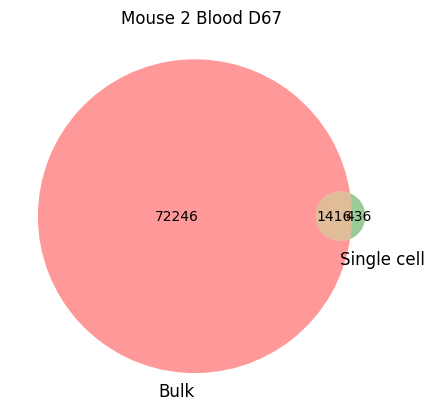

In [175]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
temp=cdr3_mouse1_spleen
venn=venn2(subsets=tuple(temp.values()), set_labels=tuple(temp.keys()))
plt.title("Mouse 2 Blood D67")
label11 = venn.get_label_by_id('11')
label01 = venn.get_label_by_id('01')
print(label11,label01)
#plt.savefig("../pictures/GFRAL/Venn_bulk_sc_mouse3_spleen.pdf")
plt.show()


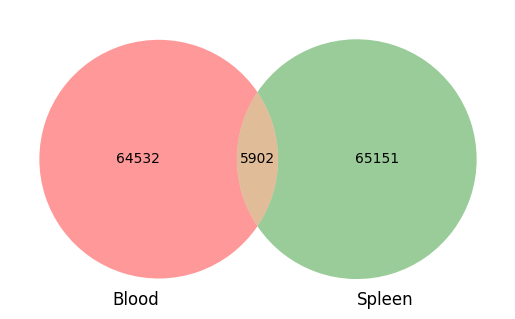

In [81]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

venn2(subsets=tuple(cdr3_blood_spleen.values()), set_labels=tuple(cdr3_blood_spleen.keys()))
#plt.title("CDR3 Sequences")
plt.savefig("../pictures/GFRAL/WANN_blood_spleen.pdf")
plt.show()


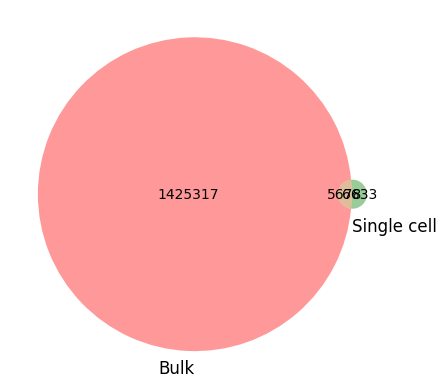

In [94]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
temp=cdr3_b_sc
venn2(subsets=tuple(temp.values()), set_labels=tuple(temp.keys()))
plt.savefig("../pictures/GFRAL/WANN_b_sc.pdf")
plt.show()


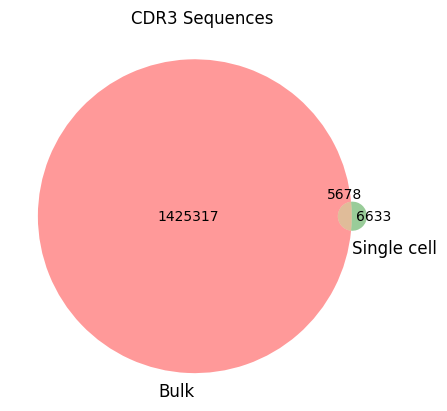

In [105]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

# Example sets (replace with your data)
temp = cdr3_b_sc
labels = list(temp.keys())
set1, set2 = temp.values()

# Compute actual counts
only1 = len(set1 - set2)
only2 = len(set2 - set1)
both = len(set1 & set2)

# Plot
venn = venn2(subsets=(only1, only2, both), set_labels=labels)

# Set counts as labels
venn.get_label_by_id('10').set_text(str(only1))
venn.get_label_by_id('01').set_text(str(only2))
label11 = venn.get_label_by_id('11')
if label11:
    label11.set_text(str(both))
    # Move it a little down or up
    x, y = label11.get_position()
    label11.set_position((x, y + 0.08))  # adjust y to move vertically
    # Try (x, y + 0.1) if you want it up instead
label01 = venn.get_label_by_id('01')
if label01:
    x, y = label01.get_position()
    label01.set_position((x + 0.05, y))  # move right; use (x, y + 0.1) for up

plt.title("CDR3 Sequences")
plt.savefig("../pictures/GFRAL/WANN_b_sc.pdf")
plt.show()



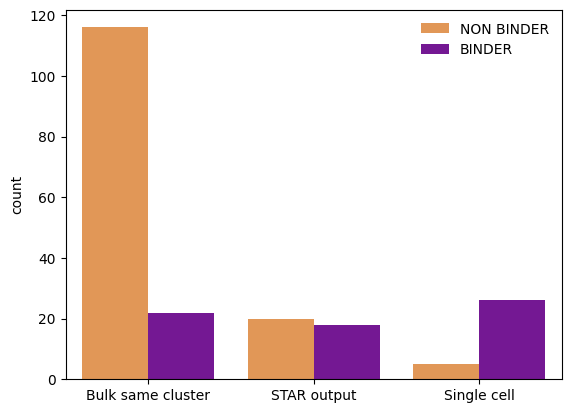

In [50]:
current_palette=sns.color_palette("plasma",3)
new_palette=current_palette[2:3]+current_palette[0:1]
sns.countplot(data=df_GFRAL_notn,x="new_cat",hue="new_binding",palette=new_palette)
plt.xlabel("")
plt.legend(frameon=False)
plt.savefig("../pictures/GFRAL/Binding_categories.pdf")
plt.show()
#plt.xticks(["Bulk same cluster","STAR output", "Single cell"])


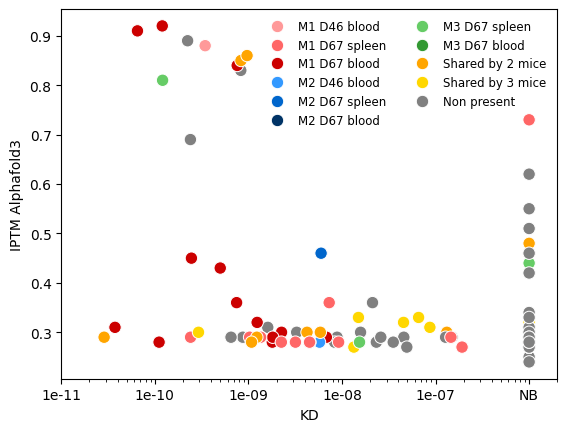

In [355]:
#plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_GFRAL_new, x="KD", y="iptm", hue="colors", palette=list(df_GFRAL_new["colors"].unique()),s=80)
plt.xscale("log")
plt.ylabel("IPTM Alphafold3")
plt.xlabel("KD")
#plt.title("Binders")
current_ticks = plt.gca().get_xticks()
new_labels = ['NB' if np.isclose(tick, 1e-6) else f'{tick:.0e}' for tick in current_ticks]
plt.xticks(current_ticks, new_labels)
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlim(1e-11,2e-6)
custom_legend_mapping = {
    '#FF9999': 'M1 D46 blood',    # light red (soft red)
    '#FF6666': 'M1 D67 spleen',   # medium red
    '#CC0000': 'M1 D67 blood',    # dark red
    '#99CCFF': 'M2 D25 blood',    # light blue (soft blue)
    '#3399FF': 'M2 D46 blood',    # medium blue
    '#0066CC': 'M2 D67 spleen',   # dark blue
    '#003366': 'M2 D67 blood',    # very dark blue
    '#99FF99': 'M3 D46 blood',    # light green
    '#66CC66': 'M3 D67 spleen',   # medium green
    '#339933': 'M3 D67 blood',    # dark green
    'grey': 'Non present',             # grey for "Non present"
    'orange': 'Shared by 2 mice',
    'gold': 'Shared by 3 mice',
}

# Desired order of labels (to match the legend mapping)
desired_order = [
    '#FF9999', '#FF6666', '#CC0000',   # M 1 colors
    '#99CCFF', '#3399FF', '#0066CC', '#003366',  # M 2 colors
    '#99FF99', '#66CC66', '#339933',   # M 3 colors
    
    'orange',                          # Shared by 2
    'gold',                             # Shared by 3
    'grey'                            # Non present
]

# Filter handles and labels based on the desired order
filtered_handles = []
filtered_labels = []
for color in desired_order:
    if color in custom_legend_mapping:
        for h, l in zip(handles, labels):
            if l == color:
                filtered_handles.append(h)
                filtered_labels.append(custom_legend_mapping[color])

# Create a new legend with the filtered handles and custom labels in the desired order
plt.legend(filtered_handles, filtered_labels, title="", frameon=False,ncol=2,loc="upper right", prop={'size': 8.5})
plt.savefig("../pictures/GFRAL/iptm_KD_sharing_with_NB.pdf")
# Show plot
plt.show()

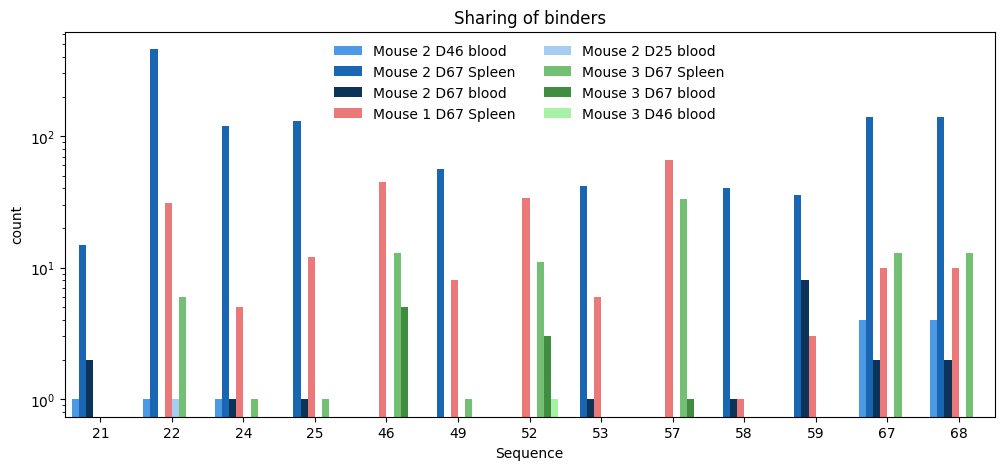

In [92]:
plt.figure(figsize=(12, 5))
sns.barplot(data=new_seq_tot, x="index", y="count", hue="new_index", palette=color_dict, errorbar=None)
plt.yscale("log")
plt.xlabel("Sequence")
plt.legend(frameon=False,ncol=2)
plt.title("Sharing of binders")
#plt.savefig("../pictures/GFRAL/Binders_categories_histogram.pdf")
plt.show()


/tmp/ipykernel_81814/2101082981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=seq_tot.sort_values(by="new_index"),x="new_index",palette="Paired")


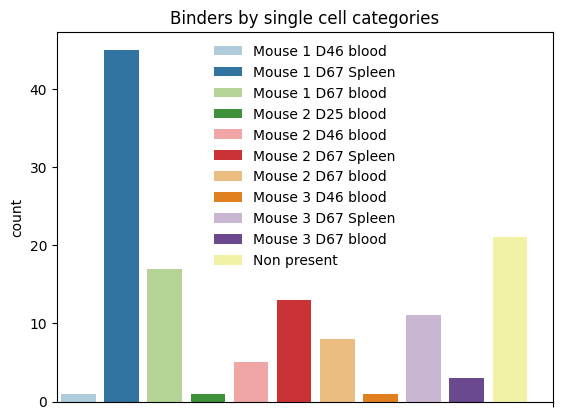

In [415]:
#seq_tot.sort_values(by="new_index",inplace=True)
sns.countplot(data=seq_tot.sort_values(by="new_index"),x="new_index",palette="Paired")
plt.legend(seq_tot.sort_values(by="new_index")["new_index"].unique(),frameon=False)
#plt.xticks(["Mouse 1","","","Mouse 2","","","","","Mouse 3","","","NP"],rotation=60)
#plt.xticks(rotation=60)
plt.xticks("")
plt.xlabel("")
plt.title("Binders by single cell categories")
plt.savefig("../pictures/GFRAL/Binders_categories.pdf")

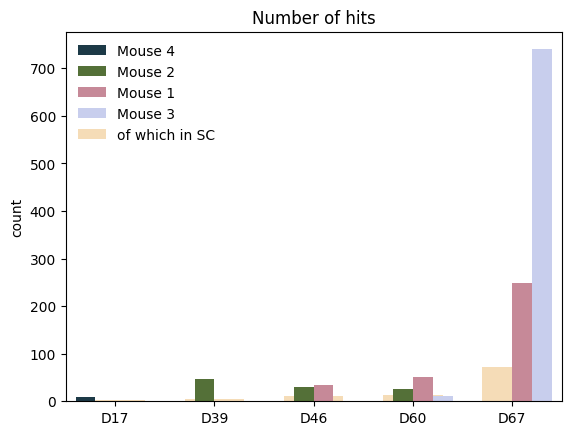

In [355]:
sns.countplot(data=hits_GFRAL_true.sort_values(by=["day","mouse"]),x="day",color="navajowhite", width=0.6)
#hits_GFRAL["mouse"]="Mouse "+ hits_GFRAL["mouse"].str[-1:]
sns.countplot(data=hits_GFRAL.sort_values(by=["day","mouse"]),x="day",hue="mouse",palette="cubehelix")

plt.xlabel("")
#plt.yscale("log")
plt.legend(["Mouse 4","Mouse 2","Mouse 1","Mouse 3","of which in SC"],frameon=False)
plt.title("Number of hits")
plt.savefig("../pictures/GFRAL/Hits_log_single_cell_comparison_nolog.pdf")
plt.show()

In [ ]:
df_39=df_read_GFRAL_all[df_read_GFRAL_all.day=="D39"]
df_60=df_read_GFRAL_all[df_read_GFRAL_all.day=="D60"]
df_3=df_read_GFRAL_all[df_read_GFRAL_all.day=="D3"]
df_60[df_60.hits==True].groupby("mouse").nb_freq.min()
df_39[df_39.hits==True].groupby("mouse").nb_freq.min()


In [103]:
mean_neigh=pd.DataFrame(index=np.arange(max(df_39["nb_neighbours_real"]+1)))
for mouse in mice:
    mean_neigh[mouse]=pd.DataFrame(df_read_GFRAL[mouse]["D39"]["nb_neighbours_real"].value_counts())
mean_neigh.fillna(0,inplace=True)

Cumulative=mean_neigh.sum()- mean_neigh.cumsum()
Cumulative.loc[-1]=mean_neigh.sum()
Cumulative.index = Cumulative.index + 1  
Cumulative = Cumulative.sort_index()
Cumulative.fillna(0,inplace=True)
Cumulative["mean"]=pd.DataFrame(Cumulative.mean(axis=1))

In [236]:
mean_neigh60=pd.DataFrame(index=np.arange(max(df_60["nb_neighbours_real"]+1)))
for mouse in mice[0:3]:
    mean_neigh60[mouse]=pd.DataFrame(df_read_GFRAL[mouse]["D60"]["nb_neighbours_real"].value_counts())
mean_neigh60.fillna(0,inplace=True)

Cumulative_D60=mean_neigh60.sum()- mean_neigh60.cumsum()
Cumulative_D60.loc[-1]=mean_neigh60.sum()
Cumulative_D60.index = Cumulative_D60.index + 1  
Cumulative_D60 = Cumulative_D60.sort_index()
Cumulative_D60.fillna(0,inplace=True)
Cumulative_D60["mean"]=pd.DataFrame(Cumulative_D60.mean(axis=1))

In [104]:
mean_neigh60=pd.DataFrame(index=np.arange(max(df_60["nb_neighbours_real"]+1)))
for mouse in mice[0:3]:
    mean_neigh60[mouse]=pd.DataFrame(df_read_GFRAL[mouse]["D60"]["nb_neighbours_real"].value_counts())
mean_neigh60.fillna(0,inplace=True)

Cumulative_D60=mean_neigh60.sum()- mean_neigh60.cumsum()
Cumulative_D60.loc[-1]=mean_neigh60.sum()
Cumulative_D60.index = Cumulative_D60.index + 1  
Cumulative_D60 = Cumulative_D60.sort_index()
Cumulative_D60.fillna(0,inplace=True)
Cumulative_D60["mean"]=pd.DataFrame(Cumulative_D60.mean(axis=1))

In [105]:
mean_neigh3=pd.DataFrame(index=np.arange(max(df_3["nb_neighbours_real"]+1)))
for mouse in mice[2:]:
    mean_neigh3[mouse]=pd.DataFrame(df_read_GFRAL[mouse]["D3"]["nb_neighbours_real"].value_counts())
mean_neigh3.fillna(0,inplace=True)

Cumulative_D3=mean_neigh3.sum()- mean_neigh3.cumsum()
Cumulative_D3.loc[-1]=mean_neigh3.sum()
Cumulative_D3.index = Cumulative_D3.index + 1  
Cumulative_D3 = Cumulative_D3.sort_index()
Cumulative_D3.fillna(0,inplace=True)
Cumulative_D3["mean"]=pd.DataFrame(Cumulative_D3.mean(axis=1))

In [148]:
treshold=[0,100,1000,90000]
x=[300,300,300,300]

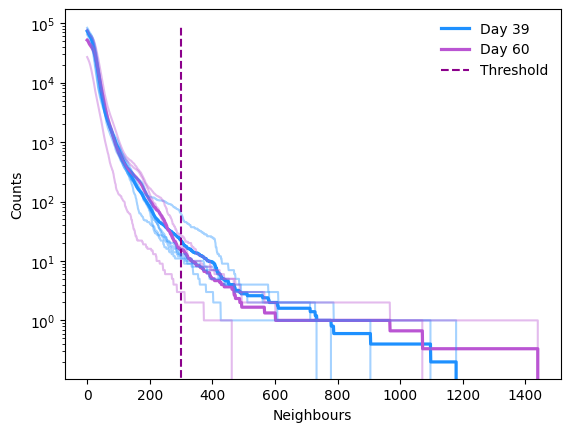

In [241]:
plt.plot(Cumulative["mean"],linewidth=2.3,c="dodgerblue")
plt.plot(Cumulative_D60["mean"],linewidth=2.3,c="mediumorchid")
plt.plot(x,treshold,"--",c="darkmagenta")
for mouse in mice:
    plt.plot(Cumulative[mouse],alpha=0.4,c="dodgerblue")


for mouse in mice[0:3]:
    plt.plot(Cumulative_D60[mouse],alpha=0.4,c="mediumorchid")


plt.ylabel("Counts")
plt.xlabel("Neighbours")
#plt.xscale("log")
plt.yscale("log")
plt.legend(["Day 39","Day 60","Threshold"],frameon=False)
plt.savefig("../pictures/GFRAL/Neighbours_nolog.pdf")
#plt.ylim(0.1,3000)
plt.show()